# ML Practical Code

## Linear Regression

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               50 non-null     str    
 1   MBA_Percentage           50 non-null     float64
 2   Salary_Package (in LPA)  50 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.5 KB


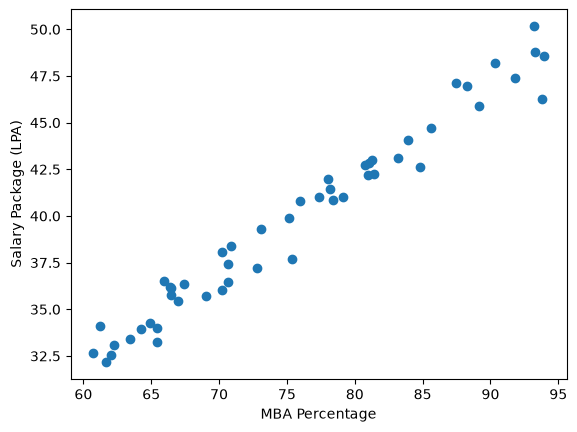

Slope (m): 0.4921495909258523
Intercept (c): 2.5936515734581604
R2 Score: 0.9502122789530665
RMSE: 0.8922978631540237


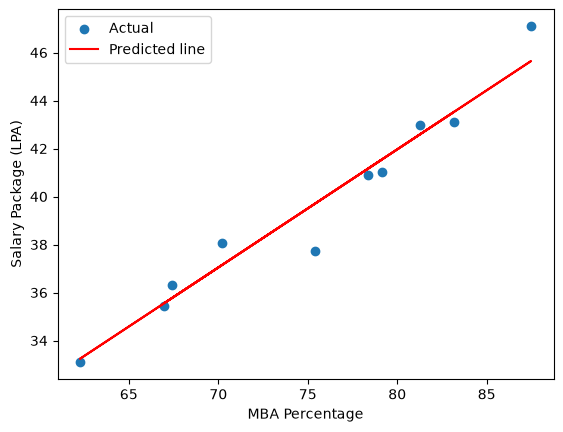

Predicted salary for 85%: 44.426366802155606


In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Step 2: Load the dataset
df = pd.read_csv("simple linear regression/mba_salary_data_ (1).csv")
df.head()

# Step 3: Explore the data
df.shape          # rows and columns
df.describe()     # mean, min, max, quartiles
df.info()         # data types and null counts

# Step 4: Features (X) and target (y)
# Double brackets keep X 2-D, which sklearn requires
X = df[["MBA_Percentage"]]
y = df["Salary_Package (in LPA)"]

# Step 5: Scatter plot to check the relationship is linear
plt.scatter(X, y)
plt.xlabel("MBA Percentage")
plt.ylabel("Salary Package (LPA)")
plt.show()

# Step 6: Split into training and testing data (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 7: Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: The fitted line  y = mx + c
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)

# Step 9: Predict on the test set
y_pred = model.predict(X_test)

# Step 10: Evaluate
# R2 = how much of the salary variation the model explains (1.0 is perfect)
# RMSE = average error, in LPA
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Step 11: Plot the regression line over the actual points
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted line")
plt.xlabel("MBA Percentage")
plt.ylabel("Salary Package (LPA)")
plt.legend()
plt.show()

# Step 12: Predict the salary of a new student
new_student = pd.DataFrame({"MBA_Percentage": [85]})
print("Predicted salary for 85%:", model.predict(new_student)[0])


## Logistic Regression

In [2]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load the dataset
df = pd.read_csv("logical regression/german_credit_risk (1).csv")
df.head()
df.shape

# Step 3: Remove the unnamed index column
df = df.drop("Unnamed: 0", axis=1)
df.isnull().sum()     # Saving accounts and Checking account have missing values

# Step 4: Fill missing categorical values with the mode (most common value)
cat_cols = ["Sex", "Housing", "Saving accounts",
            "Checking account", "Purpose"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Step 5: Convert categorical columns into dummy (0/1) variables
# drop_first=True avoids the dummy variable trap
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Step 6: Convert the target into numbers
df["Risk"] = df["Risk"].map({"bad": 0, "good": 1})

# Step 7: Features (X) and target (y)
X = df.drop("Risk", axis=1)
y = df["Risk"]

# Step 8: Split the data
# stratify=y keeps the same good/bad ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Step 9: Feature scaling
# fit_transform on train only, transform on test (never fit on test data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 10: Train the model
# max_iter=1000 stops the convergence warning
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Step 11: Predict on the test set
y_pred = model.predict(X_test_scaled)

# Step 12: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))            # rows = actual, columns = predicted
print(classification_report(y_test, y_pred))       # precision, recall, f1-score

# Step 13: Create a new customer
new_customer = pd.DataFrame({
    "Age": [30],
    "Sex": ["male"],
    "Job": [2],
    "Housing": ["own"],
    "Saving accounts": ["little"],
    "Checking account": ["moderate"],
    "Credit amount": [4000],
    "Duration": [24],
    "Purpose": ["car"]
})

# Step 14: Apply the SAME preprocessing used on the training data
# reindex forces the new row to have exactly the training columns
new_customer = pd.get_dummies(new_customer, columns=cat_cols, drop_first=True)
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

# Step 15: Scale with the same scaler, then predict
new_customer_scaled = scaler.transform(new_customer)
prediction = model.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Prediction: GOOD CREDIT RISK")
else:
    print("Prediction: BAD CREDIT RISK")

# Step 16: Probability of each class (column 1 = good risk)
probability = model.predict_proba(new_customer_scaled)
print("Probability of Good Risk:", probability[0][1])


Accuracy: 0.7
[[ 15  45]
 [ 15 125]]
              precision    recall  f1-score   support

           0       0.50      0.25      0.33        60
           1       0.74      0.89      0.81       140

    accuracy                           0.70       200
   macro avg       0.62      0.57      0.57       200
weighted avg       0.66      0.70      0.66       200

Prediction: GOOD CREDIT RISK
Probability of Good Risk: 0.5452266082339331


## Decision Tree

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB
Accuracy: 1.0
confusion matrix: [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


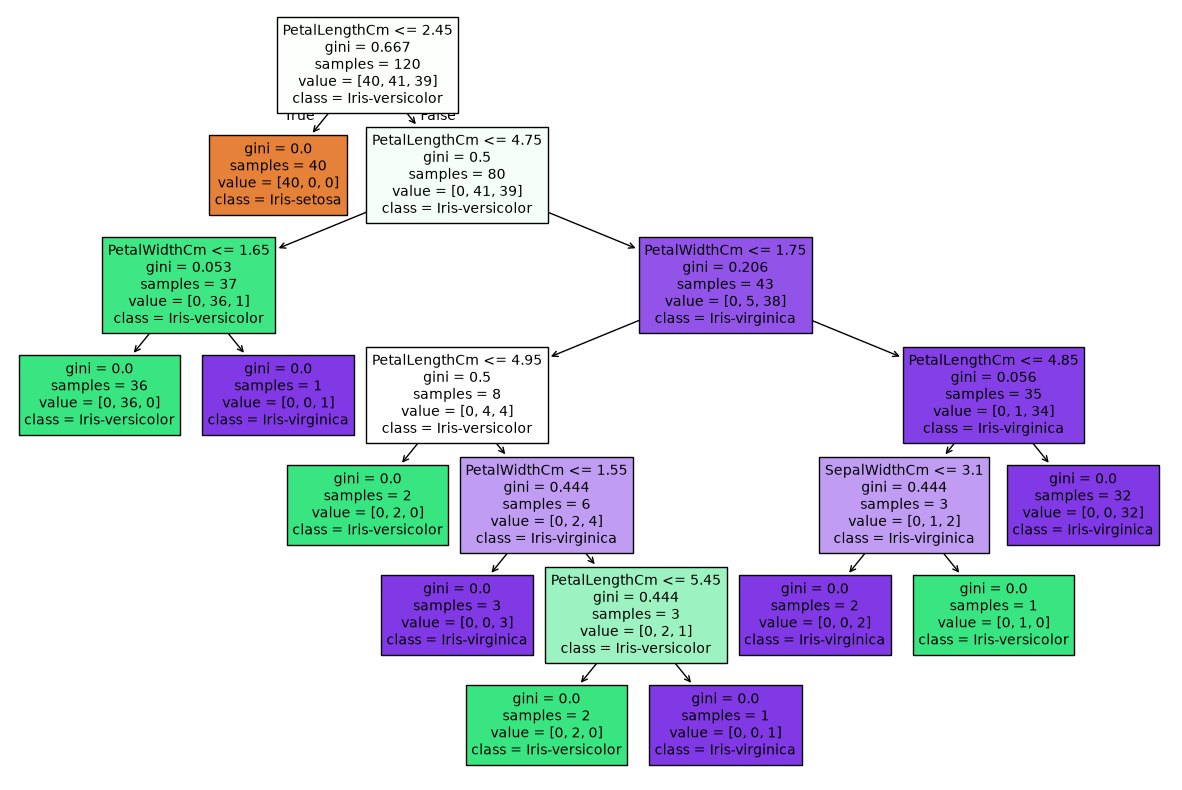

In [3]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 2: Load the dataset
df = pd.read_csv("decision tree/Iris (1).csv")
df.head()

# Step 3: Explore the data
df.shape
df.describe()
df.info()

# Step 4: Features (X) and target (Y)
# Id is just a row number, so it is left out
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
Y = df["Species"]

# Step 5: Split into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# Step 6: Train the model
# criterion="gini" measures node impurity (entropy is the alternative)
# Trees do not need feature scaling
model = DecisionTreeClassifier(criterion="gini", random_state=42)
model.fit(X_train, Y_train)

# Step 7: Predict
Y_pred = model.predict(X_test)

# Step 8: Evaluate
print("Accuracy:", accuracy_score(Y_test, Y_pred))

cm = confusion_matrix(Y_test, Y_pred)
print("confusion matrix:", cm)

# Step 9: Draw the tree so the decision rules can be read
plt.figure(figsize=(15, 10))
plot_tree(model,
          feature_names=X.columns,
          class_names=model.classes_,
          filled=True)
plt.show()


## Random Forest

Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



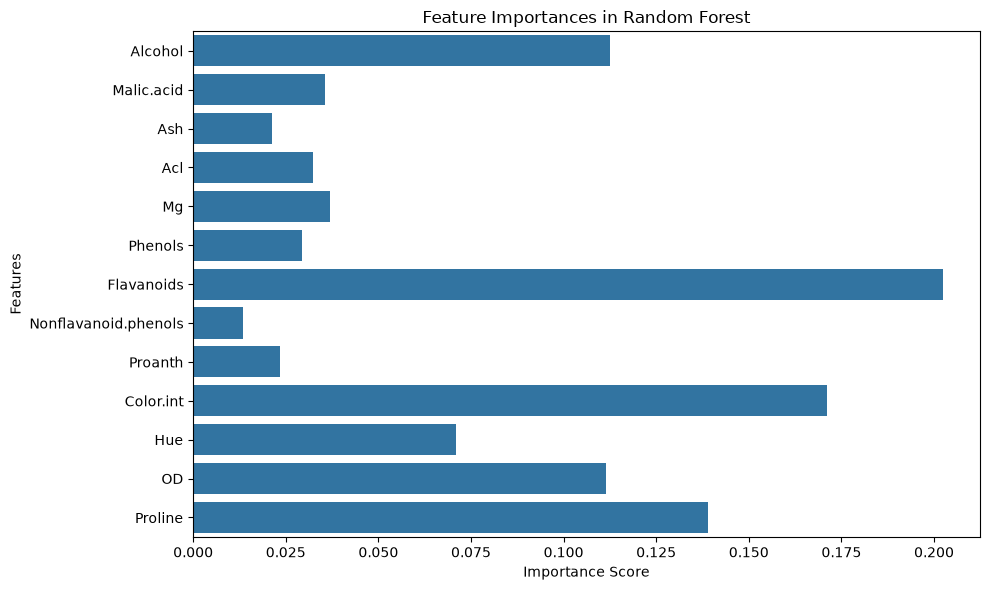

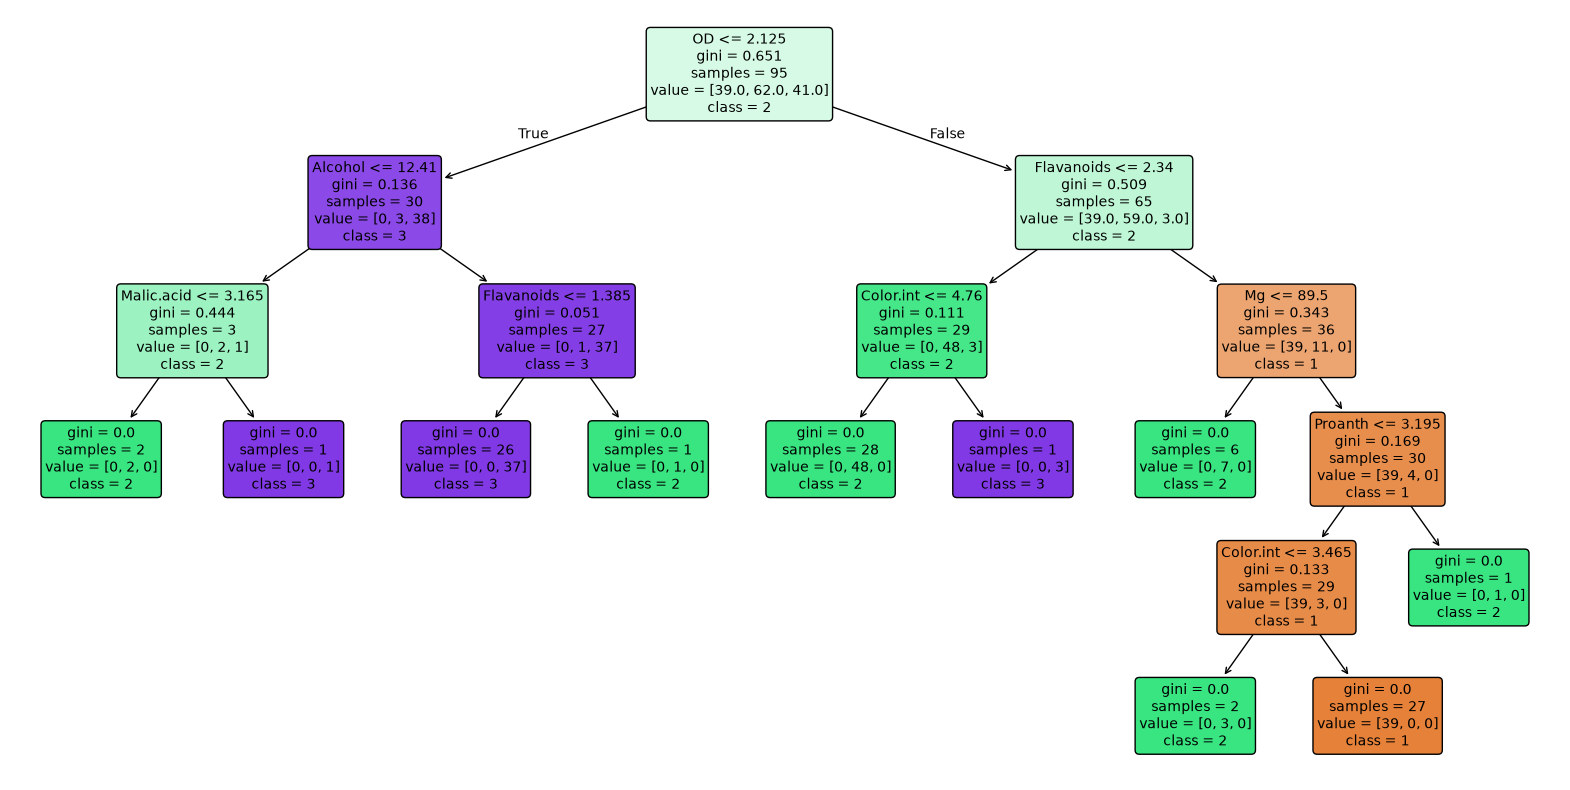

In [4]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree

# Step 2: Load the dataset
df = pd.read_csv("random forest/wine (1).csv")
df.head()
df.shape

# Step 3: Features (X) and target (y)
# "Wine" is the cultivar: class 1, 2 or 3
X = df.drop(columns=['Wine'])
y = df['Wine']

# Step 4: Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 5: Train the forest
# n_estimators=100 means 100 trees vote on each prediction
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 6: Predict
y_pred = rf.predict(X_test)

# Step 7: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Step 8: Feature importances - which chemicals decide the cultivar
plt.figure(figsize=(10, 6))
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title("Feature Importances in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Step 9: Visualise one single tree out of the 100
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0],
          filled=True,
          feature_names=X.columns,
          class_names=[str(cls) for cls in rf.classes_],
          rounded=True,
          fontsize=10)
plt.show()


## KNN

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1000 non-null   str    
 1   Gender            1000 non-null   str    
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   str    
 4   Dependents        1000 non-null   str    
 5   TenureMonths      1000 non-null   int64  
 6   InternetService   1000 non-null   str    
 7   Contract          1000 non-null   str    
 8   PaymentMethod     1000 non-null   str    
 9   TechSupport       1000 non-null   str    
 10  OnlineSecurity    1000 non-null   str    
 11  DeviceProtection  1000 non-null   str    
 12  PaperlessBilling  1000 non-null   str    
 13  MonthlyCharges    1000 non-null   float64
 14  TotalCharges      1000 non-null   float64
 15  Churn             1000 non-null   str    
dtypes: float64(2), int64(2), str(12)
memory usage: 185.2 K

C:\Users\Tatianv3\AppData\Local\Temp\ipykernel_21740\3657693871.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Accuracy: 0.63
[[95 31]
 [43 31]]
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       126
           1       0.50      0.42      0.46        74

    accuracy                           0.63       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.62      0.63      0.62       200



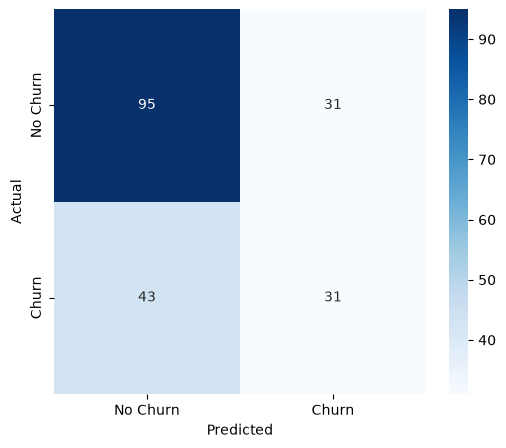

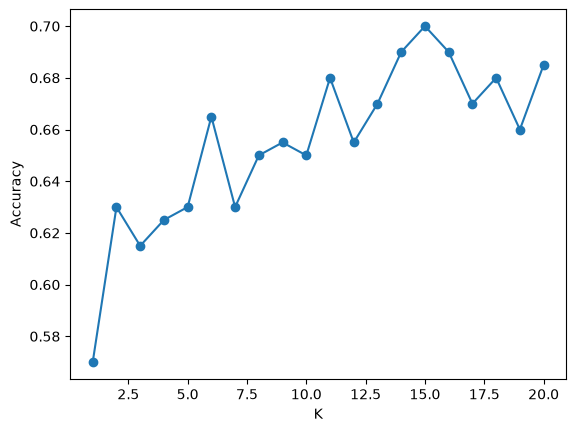

Best K: 15


In [5]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load the dataset
df = pd.read_csv("knn/Customer_Churn_Dataset (1).csv")
df.head()
df.shape
df.info()

# Step 3: Drop the ID column - it carries no information
df = df.drop("CustomerID", axis=1)

# Step 4: Convert the target into numbers
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Step 5: Convert all remaining text columns into dummy variables
cat_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Step 6: Features (X) and target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Step 7: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Step 8: Feature scaling - COMPULSORY for KNN
# KNN measures distance, so TotalCharges (thousands) would otherwise
# completely outweigh columns like SeniorCitizen (0 or 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 9: Train the model with K = 5 neighbours
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Step 10: Predict
y_pred = knn.predict(X_test_scaled)

# Step 11: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

# Step 12: Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 13: Try K from 1 to 20 and pick the best one
scores = []

for k in range(1, 21):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    scores.append(accuracy_score(y_test, m.predict(X_test_scaled)))

plt.plot(range(1, 21), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

print("Best K:", scores.index(max(scores)) + 1)


## Sentiment Analysis

Training data: 700
Testing data : 300
Number of TF-IDF features: 48
Accuracy : 0.5566666666666666
Precision: 0.5606060606060606
Recall   : 0.2624113475177305
F1 Score : 0.357487922705314


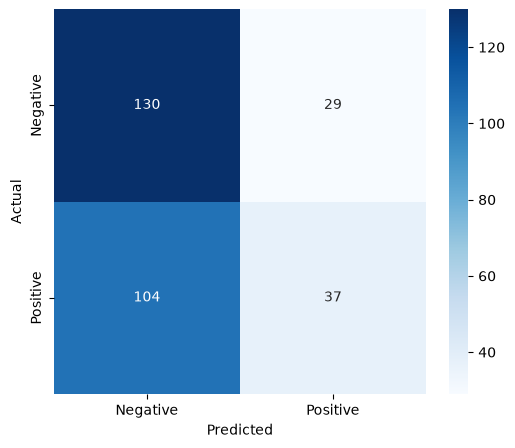

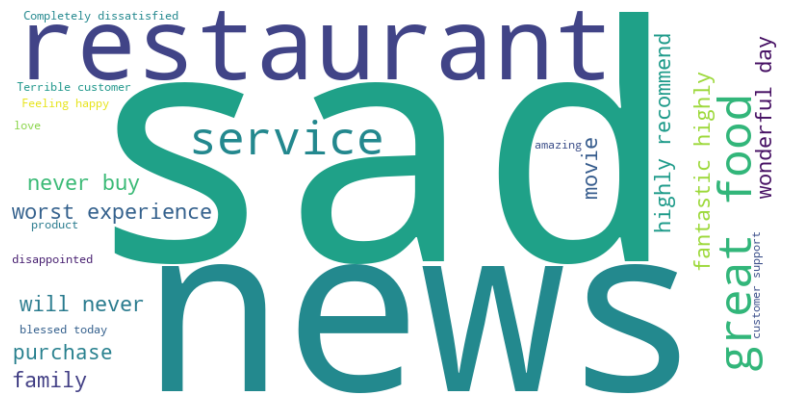

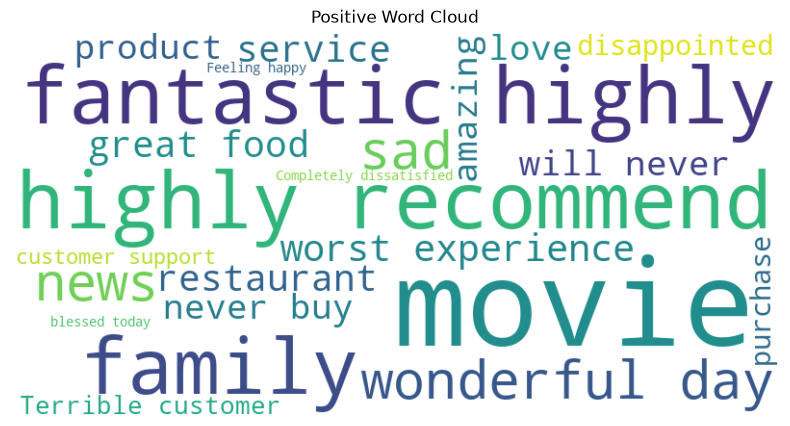

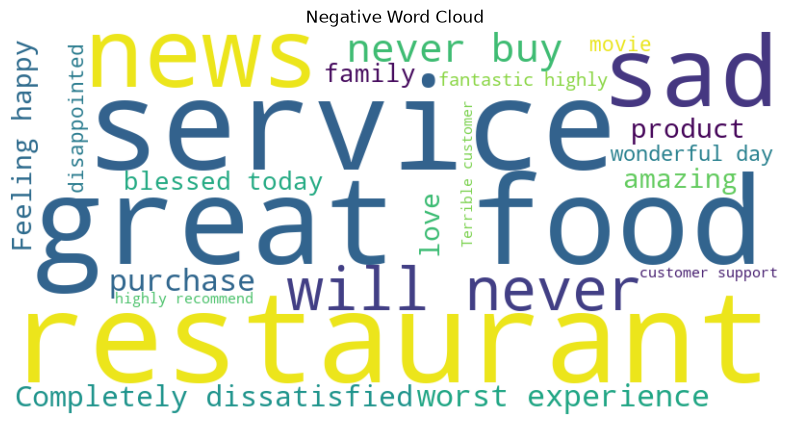

Predicted Sentiment: negative


In [6]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Step 2: Load the dataset
df = pd.read_csv("sentiment analysis/tweets_dataset.csv")
df.head()
df.shape

# Step 3: Prepare the data
# fillna("") avoids errors on empty tweets, lower/strip cleans the labels
X = df["tweet"].fillna("")
y = df["sentiment"].str.lower().str.strip()

# Step 4: Train-test split (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print("Training data:", len(X_train))
print("Testing data :", len(X_test))

# Step 5: TF-IDF - convert the text into numbers
# A word scores high if it is common in one tweet but rare overall
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Number of TF-IDF features:", X_train_tfidf.shape[1])

# Step 6: Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Step 7: Predict
y_pred = model.predict(X_test_tfidf)

# Step 8: Evaluate
# pos_label="positive" is needed because the labels are text, not 0/1
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="positive", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, pos_label="positive", zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="positive", zero_division=0))

# Step 9: Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 10: Word cloud of all tweets - bigger word = more frequent
all_text = " ".join(df["tweet"].astype(str))
wordcloud = WordCloud(width=800, height=400,
                      background_color="white").generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Step 11: Separate word clouds for positive and negative tweets
positive_text = " ".join(df[df["sentiment"] == "positive"]["tweet"].astype(str))
negative_text = " ".join(df[df["sentiment"] == "negative"]["tweet"].astype(str))

for text, title in [(positive_text, "Positive Word Cloud"),
                    (negative_text, "Negative Word Cloud")]:
    wc = WordCloud(width=800, height=400,
                   background_color="white").generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Step 12: Predict the sentiment of a new review
# transform only - never fit_transform on new data
new_review = ["I really enjoyed this product. It is excellent!"]
print("Predicted Sentiment:", model.predict(tfidf.transform(new_review))[0])


## ARIMA

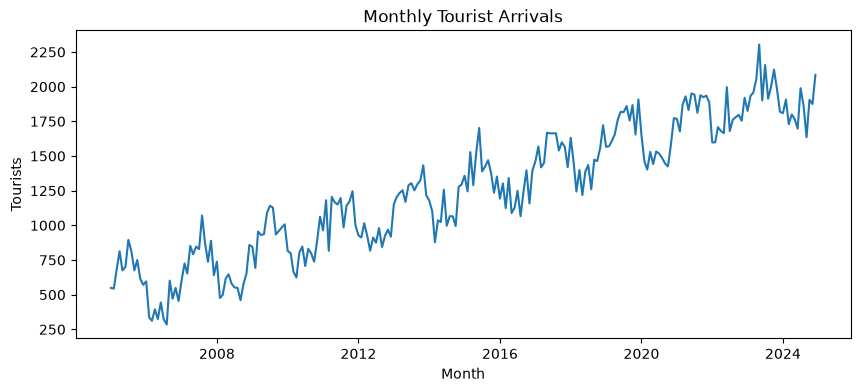

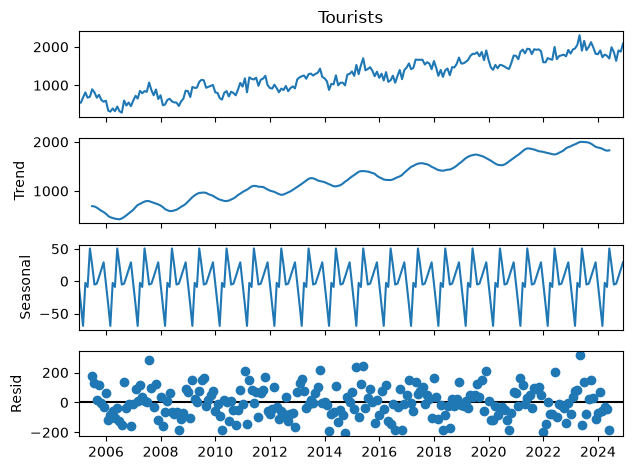

Training data: 216
Testing data : 24
                               SARIMAX Results                                
Dep. Variable:               Tourists   No. Observations:                  216
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1348.521
Date:                Fri, 18 Sep 2026   AIC                           2703.041
Time:                        20:19:19   BIC                           2713.153
Sample:                    01-01-2005   HQIC                          2707.127
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2208      0.168     -1.315      0.189      -0.550       0.108
ma.L1         -0.2220      0.179     -1.239      0.215      -0.573       0.129
sigma2      1.6

C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


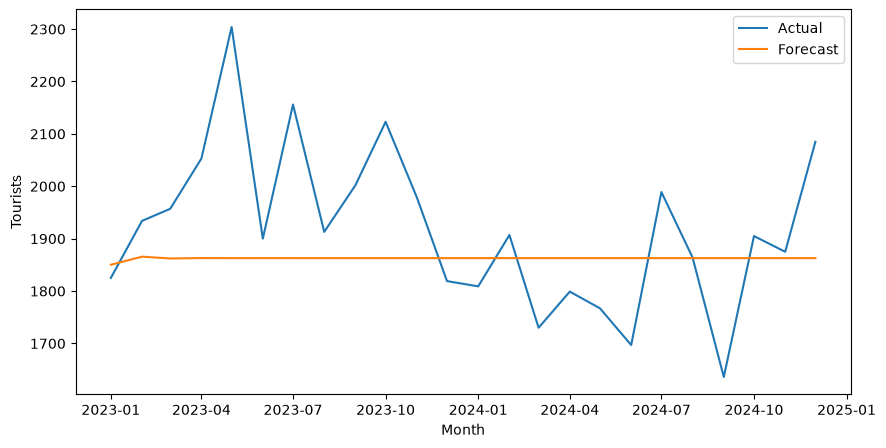

The forecast has good accuracy.
            Actual  Forecast
Month                       
2023-01-01  1825.0   1850.23
2023-02-01  1934.0   1865.64
2023-03-01  1957.0   1862.24
2023-04-01  2053.0   1862.99
2023-05-01  2304.0   1862.82
2023-06-01  1900.0   1862.86
2023-07-01  2156.0   1862.85
2023-08-01  1913.0   1862.85
2023-09-01  2002.0   1862.85
2023-10-01  2123.0   1862.85
2023-11-01  1979.0   1862.85
2023-12-01  1819.0   1862.85
2024-01-01  1809.0   1862.85
2024-02-01  1907.0   1862.85
2024-03-01  1730.0   1862.85
2024-04-01  1799.0   1862.85
2024-05-01  1767.0   1862.85
2024-06-01  1697.0   1862.85
2024-07-01  1989.0   1862.85
2024-08-01  1864.0   1862.85
2024-09-01  1636.0   1862.85
2024-10-01  1905.0   1862.85
2024-11-01  1875.0   1862.85
2024-12-01  2085.0   1862.85


In [7]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

# Step 2: Load the dataset
df = pd.read_csv("time series/tourism_data_2005_onwards (1).csv")
df.head()
df.shape

# Step 3: Turn the Month column into a time-series index
# dayfirst=True because the dates are DD-MM-YYYY
df["Month"] = pd.to_datetime(df["Month"], dayfirst=True)
df = df.sort_values("Month")
df["Month"] = df["Month"].dt.to_period("M").dt.to_timestamp()
df = df.set_index("Month")

tourists = df["Tourists"].astype(float)

# Step 4: Plot the series - look for trend and seasonality
plt.figure(figsize=(10, 4))
plt.plot(tourists)
plt.title("Monthly Tourist Arrivals")
plt.xlabel("Month")
plt.ylabel("Tourists")
plt.show()

# Step 5: Decomposition into trend + seasonal + residual
# period=12 because the data is monthly
result = seasonal_decompose(tourists, model="additive", period=12)
result.plot()
plt.show()

# Step 6: Split the data CHRONOLOGICALLY - never shuffle a time series
# The last 24 months are the test set
train = tourists[:-24]
test = tourists[-24:]

print("Training data:", len(train))
print("Testing data :", len(test))

# Step 7: Build the ARIMA model
# order = (p, d, q):  p = AR lags, d = differencing, q = MA terms
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

# Step 8: Forecast the same number of months as the test set
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index      # match the dates so they plot together
print(forecast)

# Step 9: MAPE - the average error as a percentage
mape = mean_absolute_percentage_error(test, forecast) * 100
print("MAPE:", round(mape, 2), "%")

# Step 10: Plot actual vs forecast
plt.figure(figsize=(10, 5))
plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")
plt.xlabel("Month")
plt.ylabel("Tourists")
plt.legend()
plt.show()

# Step 11: Interpretation - under 10% MAPE is a good forecast
if mape < 10:
    print("The forecast has good accuracy.")
else:
    print("The forecast has higher error.")

# Step 12: Actual and forecast side by side
result_df = pd.DataFrame({"Actual": test, "Forecast": forecast})
print(result_df.round(2))


# Exam Prep — September 2025 Paper (ITS2209)

**What changes on exam day:** the dataset file, the column names, and the split ratio.
Nothing else. Every one of those sits in a **Settings** cell at the top of each question,
marked `# <<< CHANGE`.

| Question | Settings you will edit |
|---|---|
| Q1 | `CSV_FILE`, `TARGET`, `TEST_SIZE` |
| Q2 | `CSV_FILE`, `TARGET`, `ID_COLUMN`, `TEST_SIZE`, `TARGET_MAP`, `CLASS_NAMES` |
| Q3 | `CSV_FILE`, `TEXT_COL`, `LABEL_COL`, `POS_LABEL`, `TEST_SIZE` |
| Q4 | `CSV_FILE`, `DATE_COL`, `VALUE_COL`, `TEST_MONTHS`, `SEASONAL_PERIOD`, `ARIMA_ORDER` |

Don't know the column names yet? Run this first:

```python
import pandas as pd
d = pd.read_csv("Data_Q1.csv")
print(d.shape); print(d.columns.tolist()); print(d.head())
```

The `Data_Q*.csv` files here are stand-ins at the exact shapes the paper specifies
(506×14, 614×13, 2599×2, 144×2). Swap in the real files from the LMS.

## Q1 — Boston Housing: Pre-processing + Multiple Linear Regression

### Settings — the only cell you edit on exam day

In [8]:
# ===================================================================
# EXAM DAY - CHANGE ONLY WHAT IS MARKED BELOW, THEN RUN ALL
# ===================================================================

CSV_FILE = "exam prep/Data_Q1.csv"   # <<< CHANGE - the file they give you, e.g. "exam prep/Data_Q1.csv"
TARGET   = "MEDV"          # <<< CHANGE - the column you are predicting
TEST_SIZE = 0.35           # <<< CHANGE - 0.35 means 65% train / 35% test

RANDOM_STATE = 42          # leave as is (keeps results repeatable)

# If you do not know the column names yet, run this first:
#     import pandas as pd; print(pd.read_csv(CSV_FILE).columns.tolist())


### Step 1: Import libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


### Step 2: Load the dataset

In [10]:
df = pd.read_csv(CSV_FILE)
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,7.2126,0.0,5.49,0,0.550,5.654,8.0,7.6958,7,573,20.3,71.28,10.66,22.6
1,7.0086,0.0,1.33,0,0.609,5.569,60.4,1.8872,4,551,17.8,164.50,7.54,23.1
2,7.1543,20.0,3.43,0,0.463,6.273,13.7,11.3673,3,614,18.4,312.36,14.69,23.5
3,0.8394,0.0,16.93,0,0.770,6.237,26.0,11.4060,4,663,13.2,360.80,29.85,11.9
4,0.2593,12.5,6.90,0,0.508,5.668,34.2,7.1066,24,649,14.5,235.74,26.93,15.4


### Step 3: Explore the data

In [11]:
print("Shape:", df.shape)     # expect 506 rows x 14 columns
df.info()


Shape: (506, 14)
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       494 non-null    float64
 6   AGE      494 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    494 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### Step 4: Summary statistics

In [12]:
df.describe()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,494.000000,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,506.000000
mean,2.989723,21.758893,13.791146,0.086957,0.620998,6.317334,48.740486,6.692212,6.167984,449.258893,17.089921,187.578893,20.218826,20.029842
std,2.944228,25.442503,7.778658,0.282050,0.141535,0.726237,28.927185,3.184068,6.028763,151.208970,2.674055,110.476738,10.474056,7.695986
min,0.024400,0.000000,0.510000,0.000000,0.380000,4.155000,2.100000,1.107100,1.000000,187.000000,12.600000,1.590000,1.710000,5.000000
25%,0.866950,0.000000,6.915000,0.000000,0.505250,5.851250,22.525000,4.067375,3.000000,320.250000,14.800000,93.562500,10.830000,14.325000
50%,2.036750,12.500000,13.605000,0.000000,0.613000,6.308000,47.800000,6.760900,5.000000,453.000000,17.000000,177.080000,21.205000,20.300000
75%,4.143950,35.000000,20.595000,0.000000,0.746750,6.835500,72.175000,9.522100,7.000000,577.000000,19.400000,276.207500,29.077500,25.600000
max,18.507300,80.000000,26.980000,1.000000,0.870000,8.123000,99.900000,12.074400,24.000000,710.000000,22.000000,396.790000,37.960000,39.900000


### (a) 1. Handle missing values

In [13]:
# Count the missing values in every column
print("Missing values before:")
print(df.isnull().sum())


Missing values before:
CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM         12
AGE        12
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      12
MEDV        0
dtype: int64


### Fill the missing values

In [14]:
# Numeric columns -> fill with the MEDIAN (median resists outliers better than the mean)
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Text columns (if any) -> fill with the MODE (most common value)
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after:", df.isnull().sum().sum())


Missing values after: 0


### (a) 2. Separate features and target

In [15]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("Features:", list(X.columns))
print("Target  :", TARGET)


Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Target  : MEDV


### (a) 2. Normalise / standardise the numerical features

In [16]:
# StandardScaler puts every feature on the same scale: mean 0, standard deviation 1.
# This matters because the features here have very different units
# (TAX is in hundreds, NOX is a fraction).
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.describe().loc[["mean", "std"]].round(3)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
mean,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


### (a) 3. Correlation heatmap

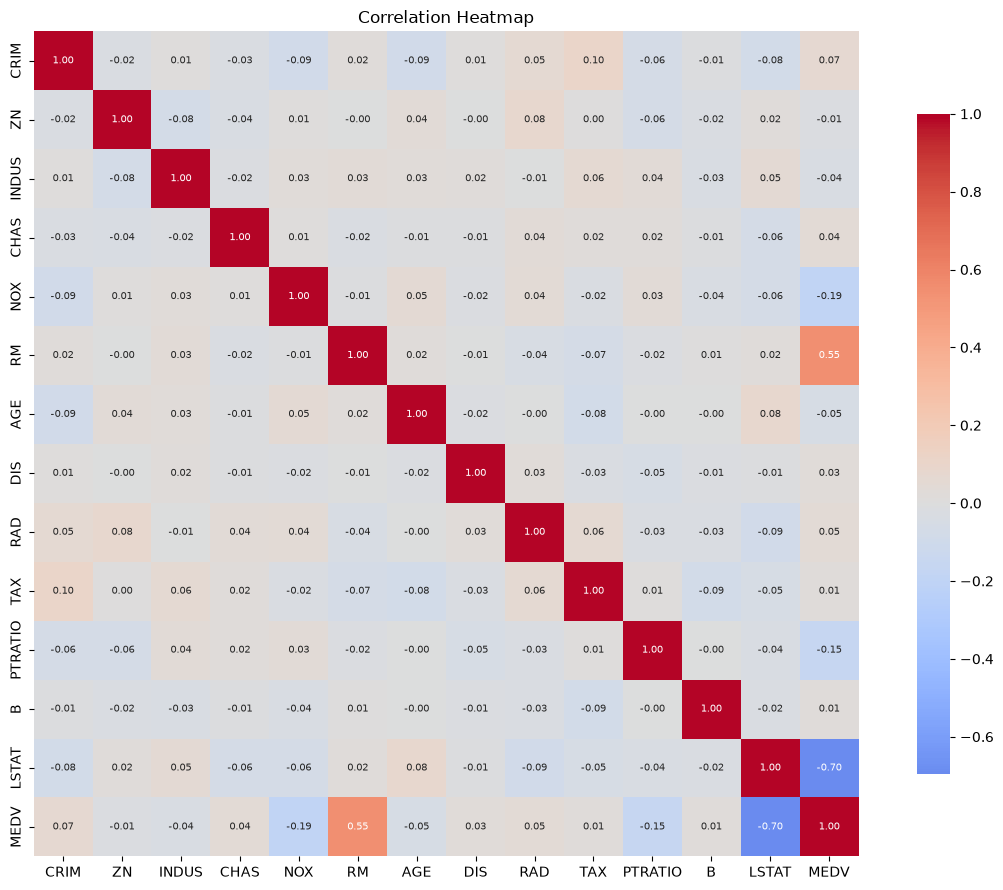

In [17]:
# The heatmap shows how strongly every pair of variables moves together.
# Look at the TARGET row/column to see which features drive the house price.
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Which features correlate most with the target?

In [18]:
# Sorted list - easier to quote in the written answer than reading the heatmap
corr_with_target = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(ascending=False)
print(corr_with_target.round(3))


RM         0.547
CRIM       0.072
RAD        0.046
CHAS       0.045
DIS        0.028
TAX        0.014
B          0.013
ZN        -0.015
INDUS     -0.037
AGE       -0.052
PTRATIO   -0.154
NOX       -0.187
LSTAT     -0.695
Name: MEDV, dtype: float64


### (b) 1. Split into training (65%) and testing (35%) sets

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 328
Testing rows : 178


### (b) 2. Train the Multiple Linear Regression model

In [20]:
# "Multiple" simply means more than one input feature.
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", round(model.intercept_, 4))


Intercept: 20.1513


### The fitted equation - one coefficient per feature

In [21]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_.round(4)
}).sort_values("Coefficient", key=abs, ascending=False)

coefficients


,Feature,Coefficient
12,LSTAT,-5.6779
5,RM,4.2291
4,NOX,-1.6708
10,PTRATIO,-1.3655
0,CRIM,-0.2430
8,RAD,0.2144
9,TAX,0.2116
1,ZN,-0.1788
11,B,0.1666
7,DIS,0.1615


### (b) 3. Predict house prices on the test set

In [22]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred.round(2)})
comparison.head(10)


,Actual,Predicted
0,22.6,26.13
1,34.0,34.13
2,18.7,22.00
3,30.5,29.05
4,19.5,21.73
5,27.9,28.05
6,8.9,13.53
7,8.5,10.55
8,19.6,21.87
9,18.0,20.86


### (b) 4. Evaluate using MSE, RMSE and MAE

In [23]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("MSE :", round(mse, 4))     # average squared error - punishes big mistakes
print("RMSE:", round(rmse, 4))    # same units as the target ($1000s)
print("MAE :", round(mae, 4))     # average absolute error - easiest to explain
print("R2  :", round(r2, 4))      # share of the variance the model explains


MSE : 7.8368
RMSE: 2.7994
MAE : 2.0604
R2  : 0.8624


### (b) 5. Visualise Actual vs Predicted values

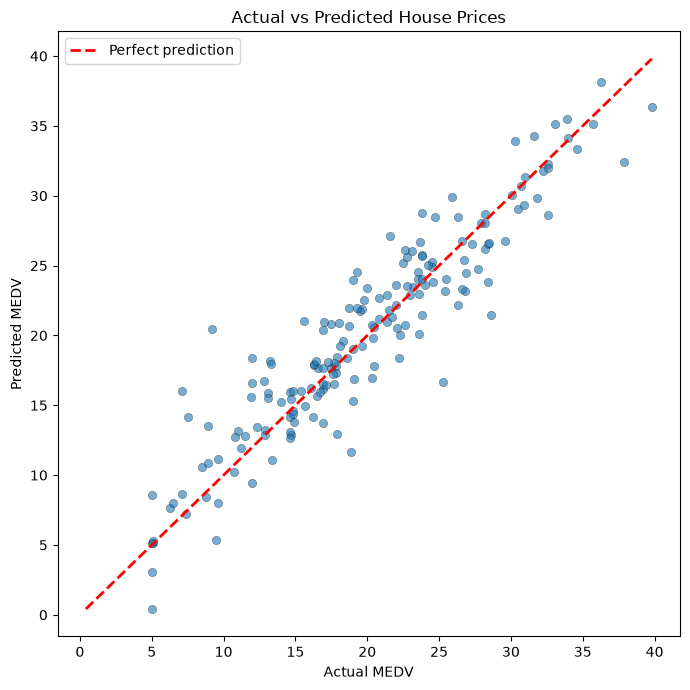

In [24]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k", linewidth=0.3)

# The 45-degree line is where a perfect prediction would sit
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")

plt.xlabel("Actual " + TARGET)
plt.ylabel("Predicted " + TARGET)
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()


### Extra: residual plot (shows whether errors are random)

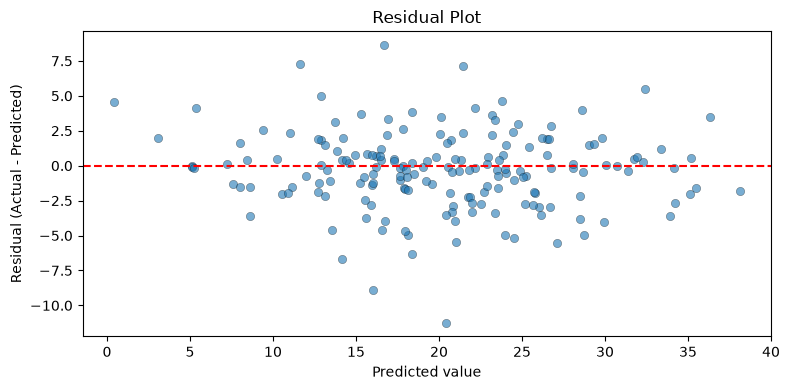

In [25]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor="k", linewidth=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted value")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


## Q2 — Loan Prediction: Decision Tree Classifier

### Settings — the only cell you edit on exam day

In [26]:
# ===================================================================
# EXAM DAY - CHANGE ONLY WHAT IS MARKED BELOW, THEN RUN ALL
# ===================================================================

CSV_FILE  = "exam prep/Data_Q2.csv"      # <<< CHANGE - the file they give you
TARGET    = "Loan_Status"      # <<< CHANGE - the column you are predicting
ID_COLUMN = "Loan_ID"          # <<< CHANGE - identifier to drop ("" if there is none)
TEST_SIZE = 0.40               # <<< CHANGE - 0.40 means 60% train / 40% test

TARGET_MAP  = {"Y": 1, "N": 0}                  # <<< CHANGE - how the target is labelled
CLASS_NAMES = ["Rejected (N)", "Approved (Y)"]  # <<< CHANGE - names for the plots

MAX_DEPTH    = 4               # tree depth - raise for accuracy, lower for a readable plot
RANDOM_STATE = 42

# If you do not know the column names yet, run this first:
#     import pandas as pd; print(pd.read_csv(CSV_FILE).columns.tolist())


### Step 1: Import libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)


### Step 2: Load the dataset

In [28]:
df = pd.read_csv(CSV_FILE)
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP01000,Male,Yes,1,Graduate,NaN,8306,0,28.0,360.0,1.0,Urban,Y
1,LP01001,Male,No,0,Graduate,No,4367,468,9.0,360.0,1.0,Semiurban,Y
2,LP01002,Male,No,1,Graduate,No,3407,1495,11.0,360.0,1.0,Urban,Y
3,LP01003,Female,No,0,Graduate,No,8731,2041,23.0,360.0,1.0,Semiurban,Y
4,LP01004,Male,No,3+,Graduate,No,10437,0,32.0,360.0,1.0,Semiurban,Y


### Step 3: Explore the data

In [29]:
print("Shape:", df.shape)     # expect 614 rows x 13 columns
df.info()


Shape: (614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(3), int64(2), str(8)
memory usage: 82.7 KB


### Step 4: Drop the identifier column

In [30]:
# An ID is unique to every row, so it cannot generalise to new applicants.
if ID_COLUMN in df.columns:
    df = df.drop(ID_COLUMN, axis=1)

df.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,NaN,8306,0,28.0,360.0,1.0,Urban,Y
1,Male,No,0,Graduate,No,4367,468,9.0,360.0,1.0,Semiurban,Y
2,Male,No,1,Graduate,No,3407,1495,11.0,360.0,1.0,Urban,Y
3,Female,No,0,Graduate,No,8731,2041,23.0,360.0,1.0,Semiurban,Y
4,Male,No,3+,Graduate,No,10437,0,32.0,360.0,1.0,Semiurban,Y


### Step 5: Handle missing values

In [31]:
print("Missing values before:")
print(df.isnull().sum())


Missing values before:
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


### Fill the missing values

In [32]:
# Text columns -> mode (most common category)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numeric columns -> median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after:", df.isnull().sum().sum())


Missing values after: 0


C:\Users\Tatianv3\AppData\Local\Temp\ipykernel_21740\371755285.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


### Step 6: Convert the target into numbers

In [33]:
# Y (approved) = 1, N (rejected) = 0
df[TARGET] = df[TARGET].map(TARGET_MAP)

print(df[TARGET].value_counts())
print()
print("Approval rate:", round(df[TARGET].mean() * 100, 1), "%")


Loan_Status
1    493
0    121
Name: count, dtype: int64

Approval rate: 80.3 %


### Step 7: Encode the categorical features

In [34]:
# One-hot encoding turns text categories into 0/1 columns.
# drop_first=True removes one column per feature to avoid the dummy variable trap.
cat_cols = df.select_dtypes(include="object").columns
print("Encoding:", list(cat_cols))

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()


Encoding: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


C:\Users\Tatianv3\AppData\Local\Temp\ipykernel_21740\670431028.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,8306,0,28.0,360.0,1.0,1,True,True,True,False,False,False,False,False,True
1,4367,468,9.0,360.0,1.0,1,True,False,False,False,False,False,False,True,False
2,3407,1495,11.0,360.0,1.0,1,True,False,True,False,False,False,False,False,True
3,8731,2041,23.0,360.0,1.0,1,False,False,False,False,False,False,False,True,False
4,10437,0,32.0,360.0,1.0,1,True,False,False,False,True,False,False,True,False


### Step 8: Features and target

In [35]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("Number of features:", X.shape[1])


Number of features: 14


### Q2.1 Split into training (60%) and testing (40%) sets

In [36]:
# stratify=y keeps the same approved/rejected ratio in both halves
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 368
Testing rows : 246


### Q2.2 Train the Decision Tree Classifier

In [37]:
# max_depth limits how deep the tree grows.
# An unlimited tree memorises the training data (overfitting) and also
# becomes impossible to read on a plot.
model = DecisionTreeClassifier(criterion="gini", max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

### Q2.2 Predict on the test set

In [38]:
y_pred = model.predict(X_test)
y_pred[:20]


array([1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1])

### Q2.3 Evaluate: Accuracy, Precision, Recall, F1-Score

In [39]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 4))


Accuracy : 0.8659
Precision: 0.9064
Recall   : 0.9293
F1 Score : 0.9177


### Q2.3 Full classification report

In [40]:
print(classification_report(y_test, y_pred,
                            target_names=CLASS_NAMES,
                            zero_division=0))


              precision    recall  f1-score   support

Rejected (N)       0.67      0.60      0.64        48
Approved (Y)       0.91      0.93      0.92       198

    accuracy                           0.87       246
   macro avg       0.79      0.77      0.78       246
weighted avg       0.86      0.87      0.86       246



### Q2.3 Confusion matrix

[[ 29  19]
 [ 14 184]]


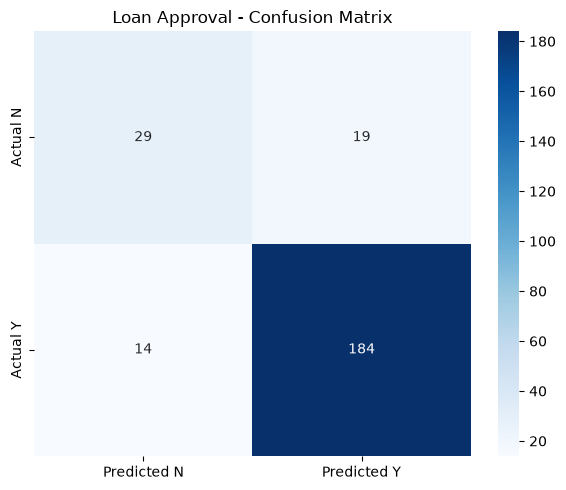

In [41]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted N", "Predicted Y"],
            yticklabels=["Actual N", "Actual Y"])
plt.title("Loan Approval - Confusion Matrix")
plt.tight_layout()
plt.show()


### Q2.4 Visualise the Decision Tree

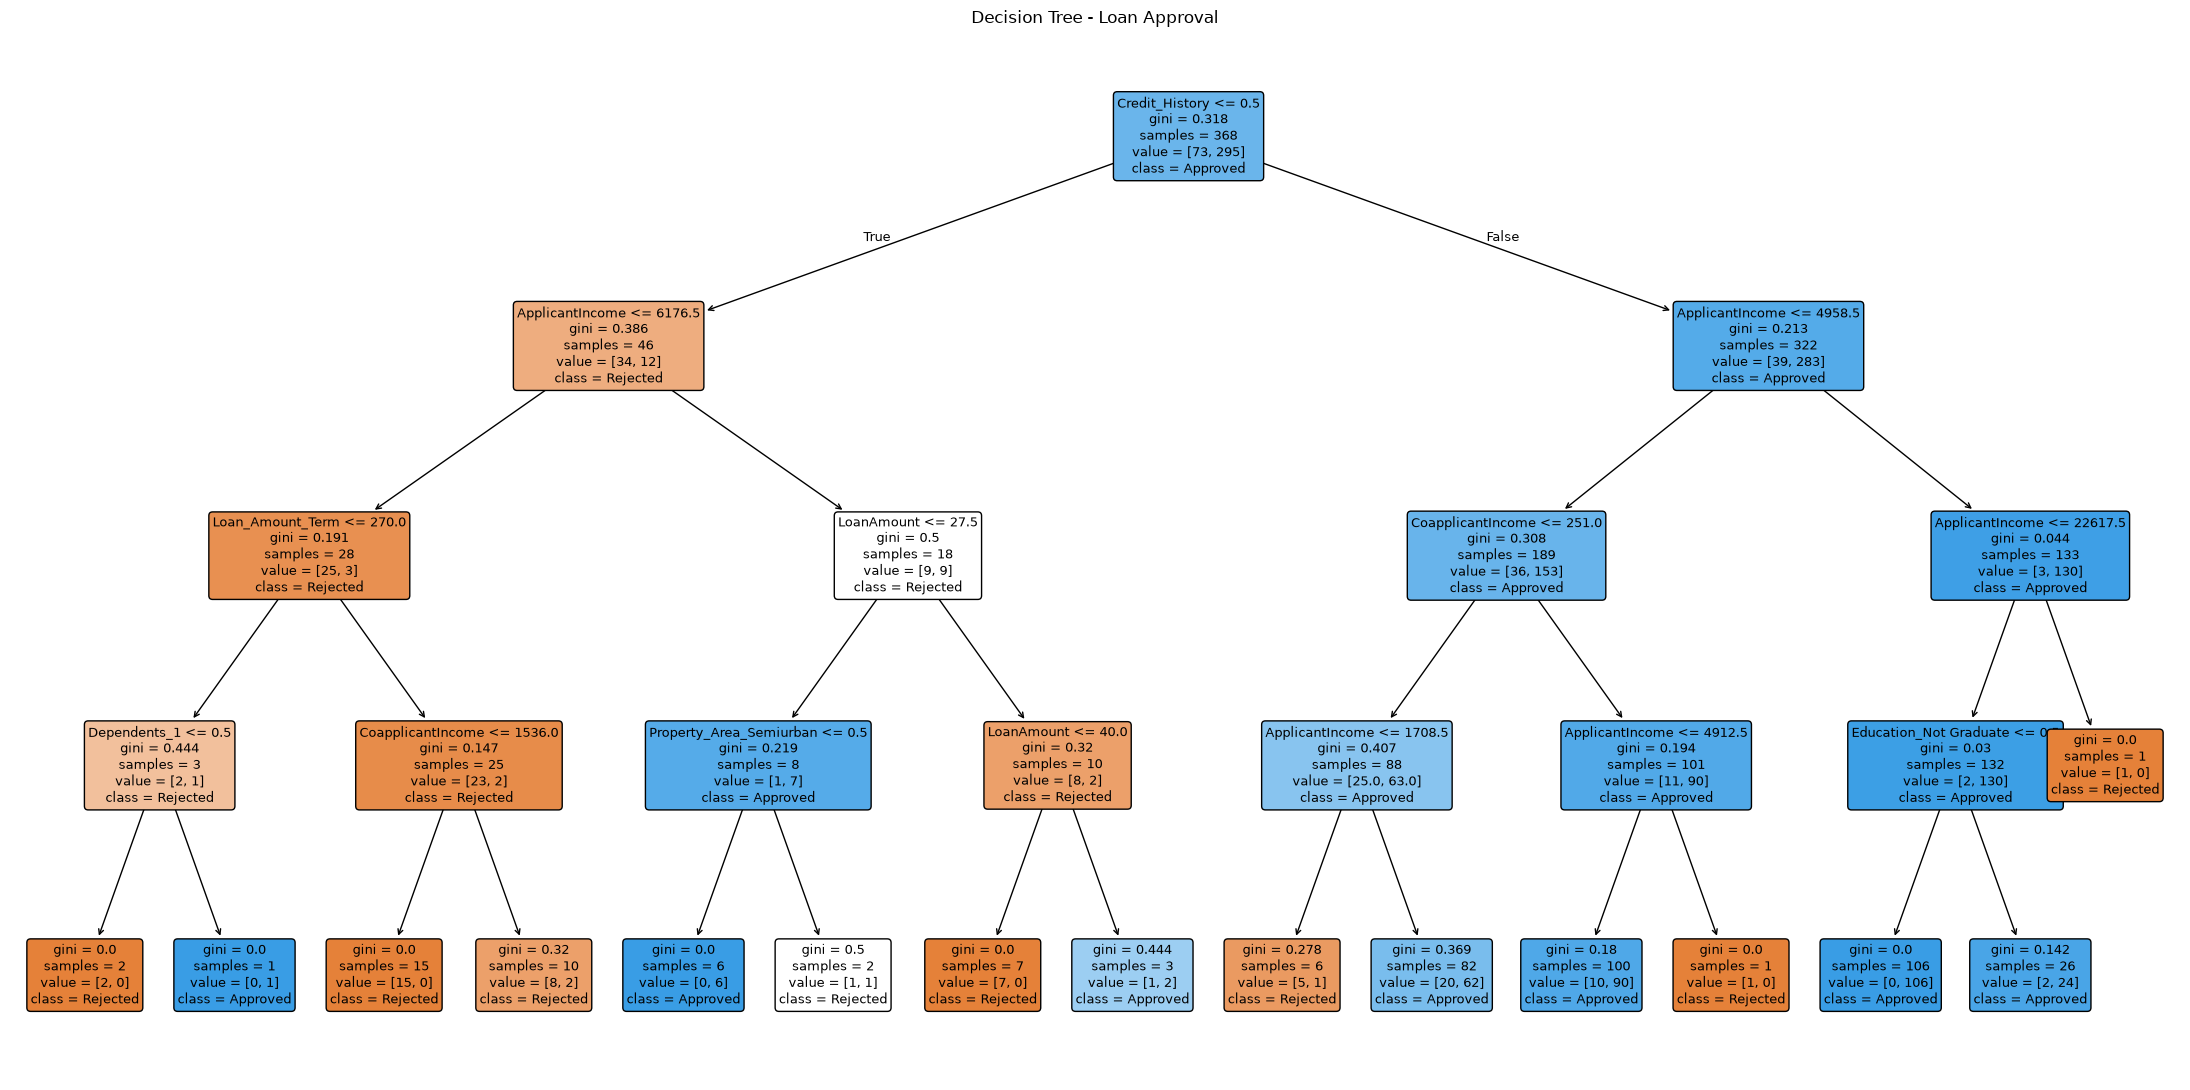

In [42]:
plt.figure(figsize=(22, 11))
plot_tree(model,
          feature_names=X.columns,
          class_names=["Rejected", "Approved"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree - Loan Approval")
plt.tight_layout()
plt.show()


### Extra: which features drive the decision?

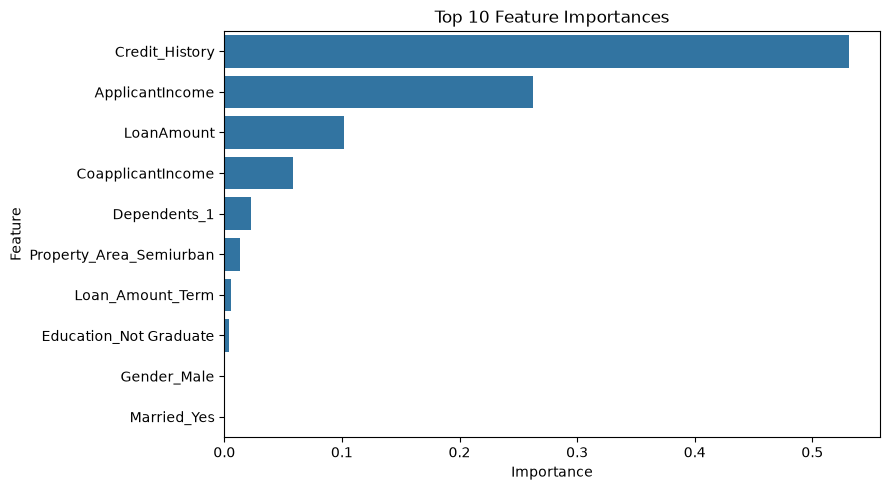

,Feature,Importance
4,Credit_History,0.5310
0,ApplicantIncome,0.2625
2,LoanAmount,0.1022
1,CoapplicantIncome,0.0581
7,Dependents_1,0.0230
12,Property_Area_Semiurban,0.0130
3,Loan_Amount_Term,0.0059
10,Education_Not Graduate,0.0043
5,Gender_Male,0.0000
6,Married_Yes,0.0000


In [43]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_.round(4)
}).sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

importances


## Q3 — IMDB Movie Reviews: Sentiment Analysis

### Settings — the only cell you edit on exam day

In [44]:
# ===================================================================
# EXAM DAY - CHANGE ONLY WHAT IS MARKED BELOW, THEN RUN ALL
# ===================================================================

CSV_FILE   = "exam prep/Data_Q3.csv"   # <<< CHANGE - the file they give you
TEXT_COL   = "Review"        # <<< CHANGE - the column holding the text
LABEL_COL  = "Sentiment"     # <<< CHANGE - the column holding positive/negative
POS_LABEL  = "positive"      # <<< CHANGE - must match a value in LABEL_COL exactly
TEST_SIZE  = 0.30            # <<< CHANGE - 0.30 means 70% train / 30% test

MAX_FEATURES = 5000          # vocabulary size for the vectoriser
RANDOM_STATE = 42

# If you do not know the column names yet, run this first:
#     import pandas as pd; d = pd.read_csv(CSV_FILE); print(d.columns.tolist()); print(d.head())


### Step 1: Import libraries

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)


### Step 2: Load the dataset

In [46]:
df = pd.read_csv(CSV_FILE)
df.head()


,Review,Sentiment
0,"One of the worst films I have seen, the acting...",negative
1,"A masterpiece of modern cinema, the cinematogr...",positive
2,"I regret watching this, the plot made no sense...",negative
3,"I regret watching this, the plot made no sense...",negative
4,"One of the worst films I have seen, the plot m...",negative


### Step 3: Explore the data

In [47]:
print("Shape:", df.shape)     # expect 2599 rows x 2 columns
df.info()


Shape: (2599, 2)
<class 'pandas.DataFrame'>
RangeIndex: 2599 entries, 0 to 2598
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Review     2599 non-null   str  
 1   Sentiment  2599 non-null   str  
dtypes: str(2)
memory usage: 265.1 KB


### Step 4: Prepare the text and the labels

In [48]:
# fillna("") guards against empty reviews, which would crash the vectoriser.
X = df[TEXT_COL].fillna("").astype(str)

# lower/strip cleans up label typos such as "Positive " vs "positive"
y = df[LABEL_COL].astype(str).str.lower().str.strip()

print(y.value_counts())


Sentiment
positive    1300
negative    1299
Name: count, dtype: int64


### Q3.1 Split into training (70%) and testing (30%) sets

In [49]:
# stratify=y keeps the positive/negative balance the same in both halves
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print("Training reviews:", len(X_train))
print("Testing reviews :", len(X_test))


Training reviews: 1819
Testing reviews : 780


### Q3.2 Convert text to numbers with TF-IDF

In [50]:
# TF-IDF = Term Frequency x Inverse Document Frequency.
# A word scores high when it appears often in ONE review but rarely across all
# reviews, so common words like "the" are automatically pushed down.
# stop_words="english" drops those filler words outright.
tfidf = TfidfVectorizer(stop_words="english", max_features=MAX_FEATURES)

X_train_vec = tfidf.fit_transform(X_train)   # fit on TRAIN only
X_test_vec  = tfidf.transform(X_test)        # then transform the test set

print("Number of features:", X_train_vec.shape[1])


Number of features: 84


### Q3.2 Alternative asked for in the question: CountVectorizer

In [51]:
# The question allows either method. CountVectorizer just counts words,
# without the inverse-document-frequency weighting.
count_vec = CountVectorizer(stop_words="english", max_features=MAX_FEATURES)
X_train_count = count_vec.fit_transform(X_train)
X_test_count  = count_vec.transform(X_test)

print("CountVectorizer features:", X_train_count.shape[1])


CountVectorizer features: 84


### Q3.3 Train the Logistic Regression model

In [52]:
# max_iter=1000 avoids the ConvergenceWarning on wide, sparse text data.
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print("Training complete.")


Training complete.


### Q3.4 Evaluate: Accuracy, Precision, Recall, F1-Score

In [53]:
# pos_label is required because the labels are words, not 0/1
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0), 4))


Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


### Q3.4 Full classification report

In [54]:
print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       390
    positive       1.00      1.00      1.00       390

    accuracy                           1.00       780
   macro avg       1.00      1.00      1.00       780
weighted avg       1.00      1.00      1.00       780



### Q3.4 Confusion matrix

[[390   0]
 [  0 390]]


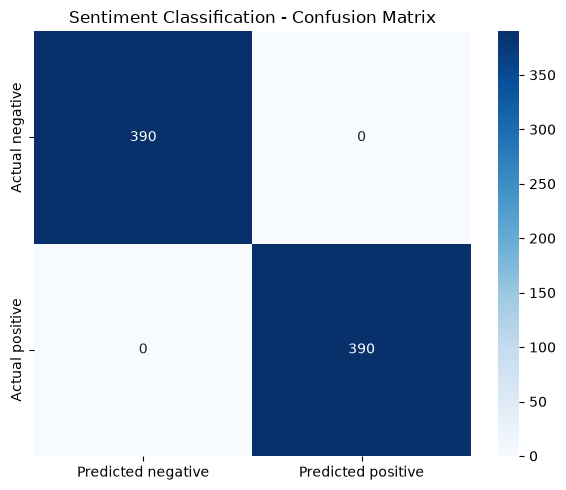

In [55]:
labels = sorted(y.unique())          # ['negative', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted " + l for l in labels],
            yticklabels=["Actual " + l for l in labels])
plt.title("Sentiment Classification - Confusion Matrix")
plt.tight_layout()
plt.show()


### Compare the two vectorisers

In [56]:
# Quick check of whether CountVectorizer does better or worse than TF-IDF
model_count = LogisticRegression(max_iter=1000)
model_count.fit(X_train_count, y_train)

print("TF-IDF accuracy          :", round(accuracy_score(y_test, y_pred), 4))
print("CountVectorizer accuracy :", round(accuracy_score(y_test, model_count.predict(X_test_count)), 4))


TF-IDF accuracy          : 1.0
CountVectorizer accuracy : 1.0


### Which words push a review positive or negative?

In [57]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
coefs = model.coef_[0]
order = np.argsort(coefs)

print("Most NEGATIVE words:", list(feature_names[order[:10]]))
print("Most POSITIVE words:", list(feature_names[order[-10:]]))


Most NEGATIVE words: ['avoid', 'bother', 'star', 'dull', 'lifeless', 'disappointed', 'sense', 'plot', 'cringeworthy', 'dialogue']
Most POSITIVE words: ['cinematography', 'gorgeous', 'beautiful', 'soundtrack', 'outstanding', 'performances', 'hooked', 'kept', 'watch', 'stars']


### Predict the sentiment of a new review

In [58]:
# A new review must go through transform() - never fit_transform()
new_reviews = [
    "Absolutely loved it, the acting was outstanding and the story moving.",
    "A complete waste of time, boring and badly written."
]

for review, prediction in zip(new_reviews, model.predict(tfidf.transform(new_reviews))):
    print(prediction.upper(), "->", review)


POSITIVE -> Absolutely loved it, the acting was outstanding and the story moving.
NEGATIVE -> A complete waste of time, boring and badly written.


## Q4 — Airline Passengers: ARIMA Forecasting

### Settings — the only cell you edit on exam day

In [59]:
# ===================================================================
# EXAM DAY - CHANGE ONLY WHAT IS MARKED BELOW, THEN RUN ALL
# ===================================================================

CSV_FILE  = "exam prep/Data_Q4.csv"    # <<< CHANGE - the file they give you
DATE_COL  = "Month"          # <<< CHANGE - the date/period column
VALUE_COL = "Passengers"     # <<< CHANGE - the number you are forecasting

TEST_MONTHS     = 24         # <<< CHANGE - how many periods to hold back for testing
SEASONAL_PERIOD = 12         # <<< CHANGE - 12 monthly, 4 quarterly, 7 daily-weekly
ARIMA_ORDER     = (1, 1, 1)  # <<< CHANGE - (p, d, q) if the question specifies one

# If you do not know the column names yet, run this first:
#     import pandas as pd; print(pd.read_csv(CSV_FILE).head())


### Step 1: Import libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_percentage_error


### Step 2: Load the dataset

In [61]:
df = pd.read_csv(CSV_FILE)
df.head()


,Month,Passengers
0,1949-01,103
1,1949-02,100
2,1949-03,122
3,1949-04,110
4,1949-05,116


### Step 3: Explore the data

In [62]:
print("Shape:", df.shape)     # expect 144 rows x 2 columns (12 years of months)
df.info()


Shape: (144, 2)
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.4 KB


### Step 4: Turn the date column into a time-series index

In [63]:
# dayfirst=True protects against DD-MM-YYYY dates being read as MM-DD-YYYY.
df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True)
df = df.sort_values(DATE_COL)                                  # time must be in order
df = df.set_index(DATE_COL)

series = df[VALUE_COL].astype(float)
series.head()


C:\Users\Tatianv3\AppData\Local\Temp\ipykernel_21740\3521557063.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True)


Month
1949-01-01    103.0
1949-02-01    100.0
1949-03-01    122.0
1949-04-01    110.0
1949-05-01    116.0
Name: Passengers, dtype: float64

### Q4.1 Plot the time series

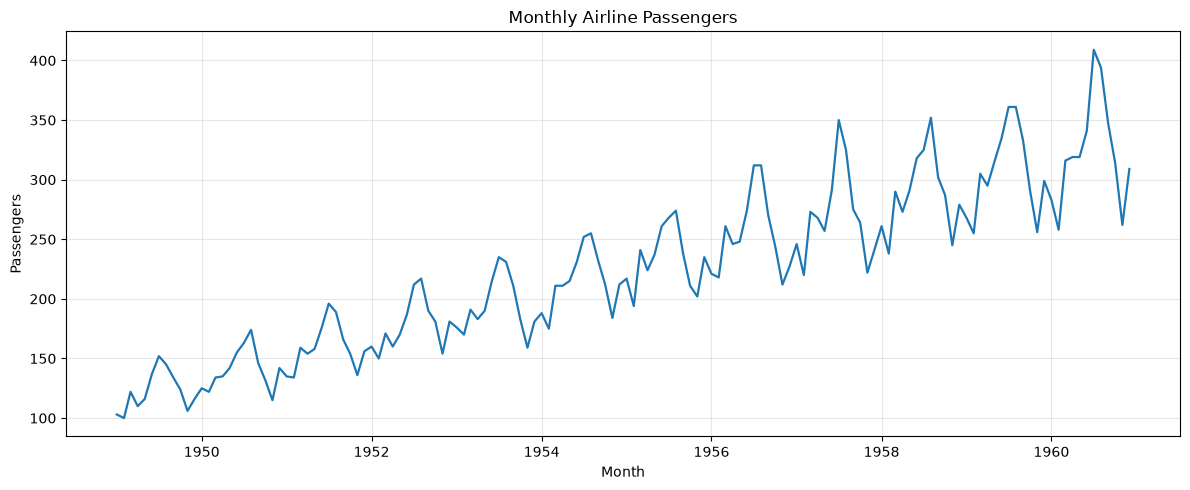

In [64]:
plt.figure(figsize=(12, 5))
plt.plot(series, linewidth=1.6)
plt.title("Monthly Airline Passengers")
plt.xlabel("Month")
plt.ylabel(VALUE_COL)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Reading the plot: a steady climb = TREND,
# the repeating yearly peaks and dips = SEASONALITY.


### Q4.2 Time series decomposition

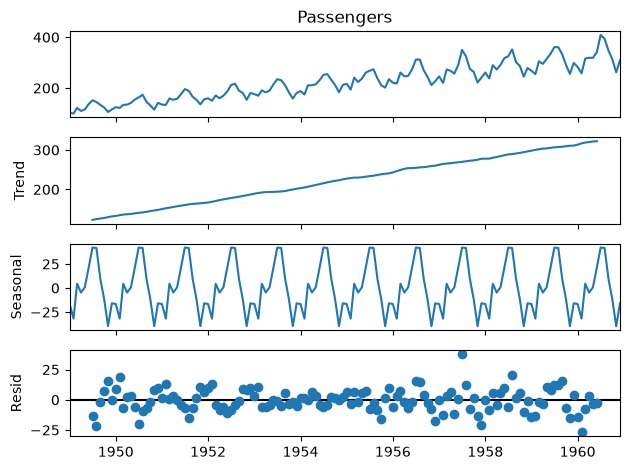

In [65]:
# Splits the series into trend + seasonal + residual (the leftover noise).
result = seasonal_decompose(series, model="additive", period=SEASONAL_PERIOD)

result.plot()
plt.tight_layout()
plt.show()


### Q4.2 The seasonal pattern month by month

In [66]:
# Averaging the seasonal component by month names the busy and quiet months.
seasonal_by_month = result.seasonal.groupby(result.seasonal.index.month).mean().round(2)
seasonal_by_month.index = ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"]
print(seasonal_by_month)


Jan   -16.57
Feb   -31.76
Mar     4.49
Apr    -4.67
May     0.74
Jun    21.42
Jul    42.05
Aug    41.59
Sep     9.53
Oct   -11.45
Nov   -39.56
Dec   -15.82
Name: seasonal, dtype: float64


### Check stationarity before fitting ARIMA

In [67]:
# ARIMA needs a stationary series (stable mean and variance).
# The ADF test: p-value below 0.05 means the series IS stationary.
def adf_test(s, label):
    p = adfuller(s.dropna())[1]
    print(label, "- p-value:", round(p, 4),
          "->", "stationary" if p < 0.05 else "NOT stationary")

adf_test(series, "Original series")
adf_test(series.diff(), "After 1 difference")   # this is the d=1 in ARIMA(p,d,q)


Original series - p-value: 0.8893 -> NOT stationary
After 1 difference - p-value: 0.0 -> stationary


### Q4.3 Split chronologically into train and test

In [68]:
# NEVER use train_test_split on a time series - it would shuffle the dates
# and let the model peek at the future. Slice by position instead.
train = series[:-TEST_MONTHS]
test  = series[-TEST_MONTHS:]

print("Training months:", len(train))
print("Testing months :", len(test))
print("Test period    :", test.index.min().date(), "to", test.index.max().date())


Training months: 120
Testing months : 24
Test period    : 1959-01-01 to 1960-12-01


### Q4.3 Train the ARIMA model

In [69]:
# ARIMA(p, d, q):
#   p = how many past VALUES to use   (AutoRegressive)
#   d = how many times to difference  (Integrated - removes the trend)
#   q = how many past ERRORS to use   (Moving Average)
model = ARIMA(train, order=ARIMA_ORDER)
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -535.048
Date:                Fri, 18 Sep 2026   AIC                           1076.095
Time:                        20:19:23   BIC                           1084.433
Sample:                    01-01-1949   HQIC                          1079.481
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6767      0.119      5.688      0.000       0.444       0.910
ma.L1         -0.8922      0.074    -12.033      0.000      -1.038      -0.747
sigma2       469.4421     64.614      7.265      0.0

C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Q4.3 Forecast the test period

In [70]:
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index          # align the dates so both plot together

pd.DataFrame({"Actual": test, "Forecast": forecast.round(1)}).head(12)


,Actual,Forecast
Month,,
1959-01-01,268.0,279.9
1959-02-01,255.0,280.5
1959-03-01,305.0,280.9
1959-04-01,295.0,281.2
1959-05-01,315.0,281.4
1959-06-01,335.0,281.5
1959-07-01,361.0,281.6
1959-08-01,361.0,281.7
1959-09-01,333.0,281.7


### Q4.4 Evaluate forecast accuracy using MAPE

In [71]:
# MAPE = Mean Absolute Percentage Error - the average error as a percentage.
# Under 10% is generally a good forecast.
mape = mean_absolute_percentage_error(test, forecast) * 100
print("MAPE:", round(mape, 2), "%")

if mape < 10:
    print("The forecast has good accuracy.")
else:
    print("The forecast has a higher error.")


MAPE: 12.42 %
The forecast has a higher error.


### Q4.4 Plot forecast against actual data

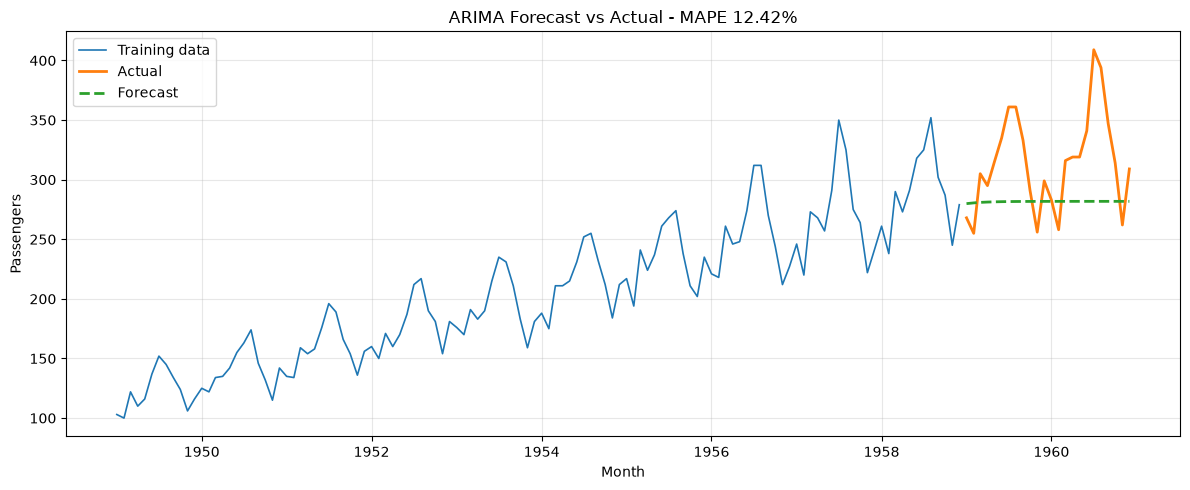

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Training data", linewidth=1.2)
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(forecast.index, forecast, label="Forecast", linewidth=2, linestyle="--")
plt.title("ARIMA Forecast vs Actual - MAPE " + str(round(mape, 2)) + "%")
plt.xlabel("Month")
plt.ylabel(VALUE_COL)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Q4.4 Zoom in on the test period only

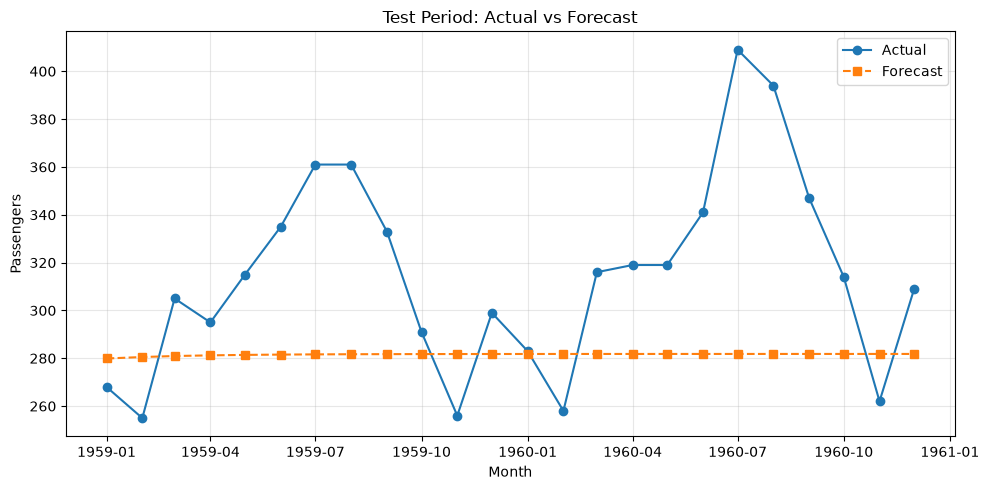

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(test.index, test, marker="o", label="Actual")
plt.plot(forecast.index, forecast, marker="s", linestyle="--", label="Forecast")
plt.title("Test Period: Actual vs Forecast")
plt.xlabel("Month")
plt.ylabel(VALUE_COL)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Comparison table

In [74]:
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast.round(1),
    "Error %": ((test - forecast).abs() / test * 100).round(2)
})
comparison


,Actual,Forecast,Error %
Month,,,
1959-01-01,268.0,279.9,4.44
1959-02-01,255.0,280.5,10.01
1959-03-01,305.0,280.9,7.89
1959-04-01,295.0,281.2,4.67
1959-05-01,315.0,281.4,10.66
1959-06-01,335.0,281.5,15.96
1959-07-01,361.0,281.6,21.98
1959-08-01,361.0,281.7,21.97
1959-09-01,333.0,281.7,15.40


### Extra: SARIMA handles the seasonality that plain ARIMA misses

In [75]:
# Plain ARIMA has no seasonal term, so its forecast comes out smoother than
# the real data. SARIMA adds a seasonal (P,D,Q,s) part - worth a mention in
# the written answer, and usually a much lower MAPE.
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train, order=ARIMA_ORDER,
                 seasonal_order=(1, 1, 1, SEASONAL_PERIOD)).fit(disp=False)

sarima_forecast = sarima.forecast(steps=len(test))
sarima_forecast.index = test.index

sarima_mape = mean_absolute_percentage_error(test, sarima_forecast) * 100
print("ARIMA  MAPE:", round(mape, 2), "%")
print("SARIMA MAPE:", round(sarima_mape, 2), "%")


C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA  MAPE: 12.42 %
SARIMA MAPE: 3.24 %
